# Half-Life Ablation Report (Recency Weighting)

**Date**: 2026-06-04  
**Window**: 20250601 ~ 20260601 (259영업일, 30종목, 14피처)  
**Method**: `LGBMTrainer.train()` with `sample_weight_half_life` exponential decay (train fold만 weighted, validation unweighted)

## 목적

**Recency weighting**(exponential decay sample weight) 도입이 LambdaRank 모델 성능에 얼마나 영향을 주는지 측정.
동일 panel/feature/walk-forward fold(train=60d/test=20d/step=20d, n_splits=8)에서 9개 grid 비교:

- `off` (unweighted baseline): 모든 row 동일 가중치
- `primary grid` (h15/h30/h45/h60/h90/h120): walk-forward train_window=60일 기준 6개
- `sensitivity grid` (h180/h365): final-window 추가 확인 2개

정책: validation은 모두 unweighted 유지. 결과는 candidate evidence only, champion/active 승격 X.

## 1. Setup

Repo root를 자동으로 찾고, 특정 ablation report 파일을 명시적으로 지정해 로드한다. 발표용 evidence이므로 timestamp를 고정해 재현성을 확보한다.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.rcParams['axes.unicode_minus'] = False


def find_repo_root() -> Path:
    """이 노트북의 위치 기준 repo root 탐색. CLAUDE.md + artifacts/ 동시 보유 디렉토리."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'CLAUDE.md').exists() and (candidate / 'artifacts').is_dir():
            return candidate
    raise FileNotFoundError('Elephant_Lab repo root를 찾지 못했습니다.')


ROOT = find_repo_root()
ABLATION_DIR = ROOT / 'artifacts' / 'reports' / 'halflife_ablation'

# 발표용 evidence: 특정 ablation report 파일을 명시적으로 고정한다.
# 같은 디렉토리에 다른 timing-mini / 추가 실험 결과가 쌓여도 본 노트북은 항상 이 파일만 분석한다.
REPORT_FILENAME = 'halflife_ablation_BUNDLE-20260603-FULL_20260603_193556.json'


def load_report(directory: Path, filename: str) -> tuple[Path, dict]:
    """특정 ablation report 파일 로드. 발표용 evidence라 timestamp 고정."""
    path = directory / filename
    if not path.exists():
        raise FileNotFoundError(f'지정한 ablation report 없음: {path}')
    with path.open(encoding='utf-8') as f:
        return path, json.load(f)


report_path, report = load_report(ABLATION_DIR, REPORT_FILENAME)
results = report['results']
tickers = report['tickers']

print(f'repo_root    : {ROOT}')
print(f'report       : {report_path.relative_to(ROOT)}')
print(f'bundle_id    : {report["bundle_id"]}')
print(f'generated_at : {report["generated_at"]}')
print(f'window       : {report["start_date"]} ~ {report["end_date"]}')
print(f'grid         : {len(report["grid"])} (off + primary 6 + sensitivity 2 = 9)')
print(f'tickers      : {len(tickers)}')

repo_root    : C:\Users\정예경\Desktop\종설_실험\AI
report       : artifacts\reports\halflife_ablation\halflife_ablation_BUNDLE-20260603-FULL_20260603_193556.json
bundle_id    : BUNDLE-20260603-FULL
generated_at : 2026-06-03T23:15:00.795849+09:00
window       : 20250601 ~ 20260601
grid         : 9 (off + primary 6 + sensitivity 2 = 9)
tickers      : 30


## 2. 데이터 정리 (results → DataFrame)

9 grid 각각의 status / metrics / fold values를 표 형태로 정리. 이후 KPI 카드 + 그래프 모두 이 DataFrame을 input으로 사용한다.

In [2]:
rows: list[dict] = []
for r in results:
    metrics = r.get('metrics') or {}
    rows.append({
        'label': r['label'],
        'half_life': r.get('half_life'),  # None for off
        'status': r['status'],
        'ic': metrics.get('ic'),
        'icir': metrics.get('icir'),
        'rank_ic': metrics.get('rank_ic'),
        'arr': metrics.get('arr'),
        'ir': metrics.get('ir'),
        'mdd': metrics.get('mdd'),
        'sr': metrics.get('sr'),
        'n_folds': r.get('n_folds'),
        'n_train_rows': r.get('n_train_rows'),
        'n_val_rows': r.get('n_val_rows'),
        'fold_ics': r.get('fold_ics') or [],
        'fold_rank_ics': r.get('fold_rank_ics') or [],
        'fold_srs': r.get('fold_srs') or [],
    })

df = pd.DataFrame(rows)
df_pass = df[df['status'] == 'PASS'].copy()

# 그래프용: weighted grid만 (off는 baseline 가로선으로 별도)
df_weighted = df_pass[df_pass['half_life'].notna()].sort_values('half_life').reset_index(drop=True)
df_off = df_pass[df_pass['half_life'].isna()].copy()

off_ic = float(df_off['ic'].iloc[0]) if not df_off.empty else float('nan')
off_rank_ic = float(df_off['rank_ic'].iloc[0]) if not df_off.empty else float('nan')
off_sr = float(df_off['sr'].iloc[0]) if not df_off.empty else float('nan')

display(df[['label', 'half_life', 'status', 'ic', 'rank_ic', 'sr', 'mdd', 'n_folds']].round(5))

,label,half_life,status,ic,rank_ic,sr,mdd,n_folds
0,off,NaN,PASS,0.13981,0.14914,32.59336,-0.00024,8
1,h15,15.0,PASS,0.13705,0.14626,32.00296,-0.00032,8
2,h30,30.0,PASS,0.13818,0.14747,31.11125,-0.00027,8
3,h45,45.0,PASS,0.13863,0.14805,31.80506,-0.00027,8
4,h60,60.0,PASS,0.13850,0.14797,32.51811,-0.00026,8
5,h90,90.0,PASS,0.13901,0.14848,32.88197,-0.00026,8
6,h120,120.0,PASS,0.13901,0.14844,31.56347,-0.00029,8
7,h180,180.0,PASS,0.13878,0.14831,31.57918,-0.00028,8
8,h365,365.0,PASS,0.13982,0.14900,33.11834,-0.00029,8


## 3. 핵심 결과 한눈에

off baseline 대비 weighted grid 최고값(IC/RankIC/SR 1위)을 KPI 카드로 표시. delta = best_weighted - off.

In [3]:
def kpi_card(title: str, value: str, sub: str, tone: str = 'neutral') -> str:
    colors = {
        'good': ('#EAF7EF', '#177245'),
        'warn': ('#FFF5DA', '#8A5A00'),
        'bad': ('#FDEAEA', '#B42318'),
        'neutral': ('#EEF4FF', '#1D4ED8'),
        'dark': ('#F4F4F5', '#27272A'),
    }
    bg, fg = colors.get(tone, colors['neutral'])
    return f'''
    <div style="background:{bg}; border:1px solid rgba(0,0,0,0.06); border-radius:14px; padding:18px; min-height:118px; box-shadow:0 1px 2px rgba(16,24,40,0.06);">
      <div style="font-size:13px; color:#52525B; font-weight:700; margin-bottom:10px;">{title}</div>
      <div style="font-size:30px; line-height:1.1; color:{fg}; font-weight:850; letter-spacing:0;">{value}</div>
      <div style="font-size:13px; color:#71717A; margin-top:10px; line-height:1.45;">{sub}</div>
    </div>
    '''


def _argmax_label(frame: pd.DataFrame, col: str) -> tuple[str, float]:
    """frame 안 col 최대값을 가진 label과 값 반환."""
    idx = frame[col].idxmax()
    return str(frame.loc[idx, 'label']), float(frame.loc[idx, col])


best_ic_label, best_ic_val = _argmax_label(df_weighted, 'ic')
best_rank_ic_label, best_rank_ic_val = _argmax_label(df_weighted, 'rank_ic')
best_sr_label, best_sr_val = _argmax_label(df_weighted, 'sr')

delta_ic = best_ic_val - off_ic
delta_rank_ic = best_rank_ic_val - off_rank_ic
delta_sr = best_sr_val - off_sr

# delta 색 분기: weighted가 분명히 좋으면 good, 거의 동일이면 warn, 더 나쁘면 bad
def _tone(delta: float, threshold: float) -> str:
    if delta > threshold:
        return 'good'
    if delta < -threshold:
        return 'bad'
    return 'warn'


n_pass = int((df['status'] == 'PASS').sum())
n_total = len(df)

cards = [
    kpi_card('off (unweighted baseline)', f'IC={off_ic:+.4f}', f'RankIC={off_rank_ic:+.4f} / SR={off_sr:+.2f}', 'neutral'),
    kpi_card(f'best IC ({best_ic_label})', f'{best_ic_val:+.4f}', f'delta vs off: {delta_ic:+.4f}', _tone(delta_ic, 1e-3)),
    kpi_card(f'best RankIC ({best_rank_ic_label})', f'{best_rank_ic_val:+.4f}', f'delta vs off: {delta_rank_ic:+.4f}', _tone(delta_rank_ic, 1e-3)),
    kpi_card(f'best SR ({best_sr_label})', f'{best_sr_val:+.2f}', f'delta vs off: {delta_sr:+.2f}', _tone(delta_sr, 0.5)),
    kpi_card('grid PASS', f'{n_pass}/{n_total}', '9 grid 전부 PASS = candidate evidence 확보', 'good' if n_pass == n_total else 'warn'),
    kpi_card('window', f'{report["start_date"][:4]}-{report["start_date"][4:6]}-{report["start_date"][6:]}', f'~ {report["end_date"][:4]}-{report["end_date"][4:6]}-{report["end_date"][6:]} (259영업일)', 'dark'),
]

html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:#FFFFFF; padding:8px 0 2px 0;">
  <div style="border-radius:18px; padding:24px; background:linear-gradient(135deg,#101828 0%,#1D4ED8 100%); color:white; margin-bottom:18px;">
    <div style="font-size:14px; opacity:.82; font-weight:700;">Half-Life Ablation Dashboard</div>
    <div style="font-size:32px; font-weight:900; margin-top:8px;">Recency Weighting (exponential decay) — off vs primary vs sensitivity</div>
    <div style="font-size:15px; opacity:.88; margin-top:8px;">Bundle: {report["bundle_id"]} / Tickers: {len(tickers)} / Grid: 9</div>
  </div>
  <div style="display:grid; grid-template-columns:repeat(3, minmax(0, 1fr)); gap:14px;">
    {''.join(cards)}
  </div>
</div>
'''
display(HTML(html))

## 4. 그래프 (1): half_life vs IC

x축은 half_life(일), y축은 IC. off (unweighted)는 별도 baseline 가로선으로 표시. weighted grid 8개 점/선.

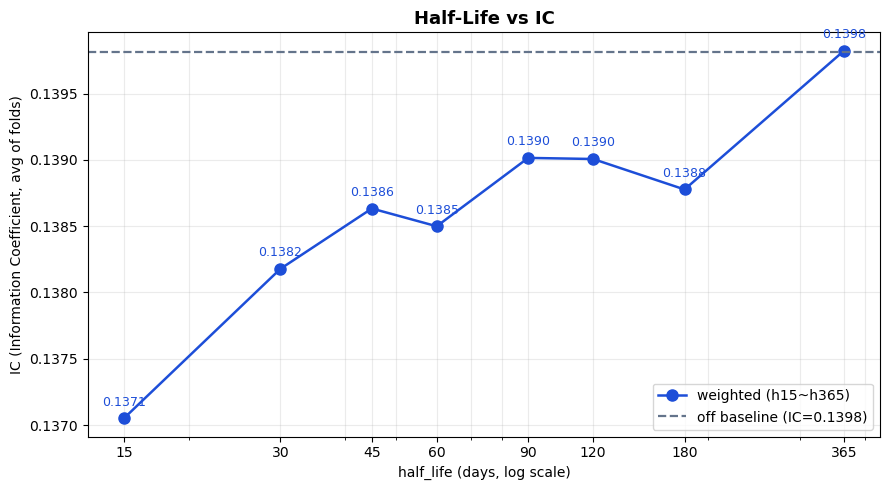

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

x = df_weighted['half_life'].astype(int).to_numpy()
y = df_weighted['ic'].astype(float).to_numpy()

ax.plot(x, y, marker='o', markersize=8, linewidth=1.8, color='#1D4ED8', label='weighted (h15~h365)')
for xi, yi, lbl in zip(x, y, df_weighted['label']):
    ax.annotate(f'{yi:.4f}', (xi, yi), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color='#1D4ED8')

ax.axhline(off_ic, color='#64748B', linestyle='--', linewidth=1.6, label=f'off baseline (IC={off_ic:.4f})')

ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x])
ax.set_xlabel('half_life (days, log scale)')
ax.set_ylabel('IC (Information Coefficient, avg of folds)')
ax.set_title('Half-Life vs IC', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. 그래프 (2): half_life vs RankIC

동일 구조. y축만 RankIC로 교체.

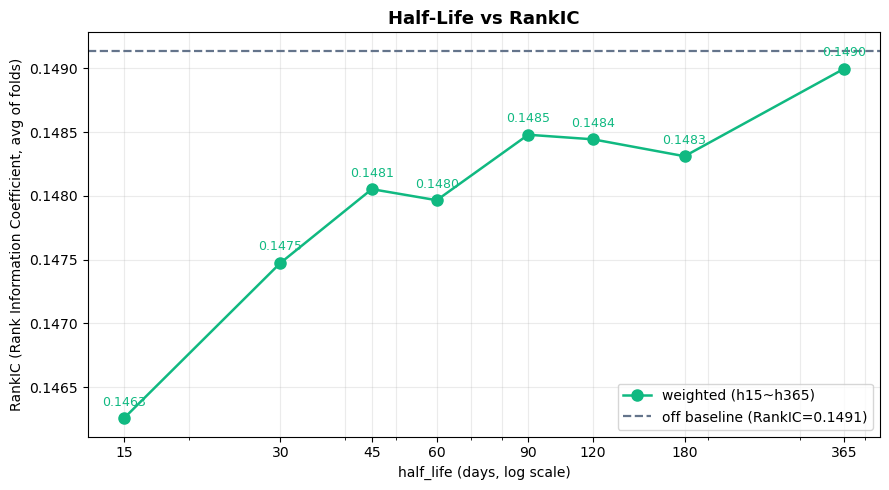

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

y = df_weighted['rank_ic'].astype(float).to_numpy()

ax.plot(x, y, marker='o', markersize=8, linewidth=1.8, color='#10B981', label='weighted (h15~h365)')
for xi, yi in zip(x, y):
    ax.annotate(f'{yi:.4f}', (xi, yi), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color='#10B981')

ax.axhline(off_rank_ic, color='#64748B', linestyle='--', linewidth=1.6, label=f'off baseline (RankIC={off_rank_ic:.4f})')

ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x])
ax.set_xlabel('half_life (days, log scale)')
ax.set_ylabel('RankIC (Rank Information Coefficient, avg of folds)')
ax.set_title('Half-Life vs RankIC', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. 그래프 (3): half_life vs SR

Sharpe Ratio. cross-sectional top-K 기반 trainer validation proxy (deploy_quality=false; C12 backtest는 별도).

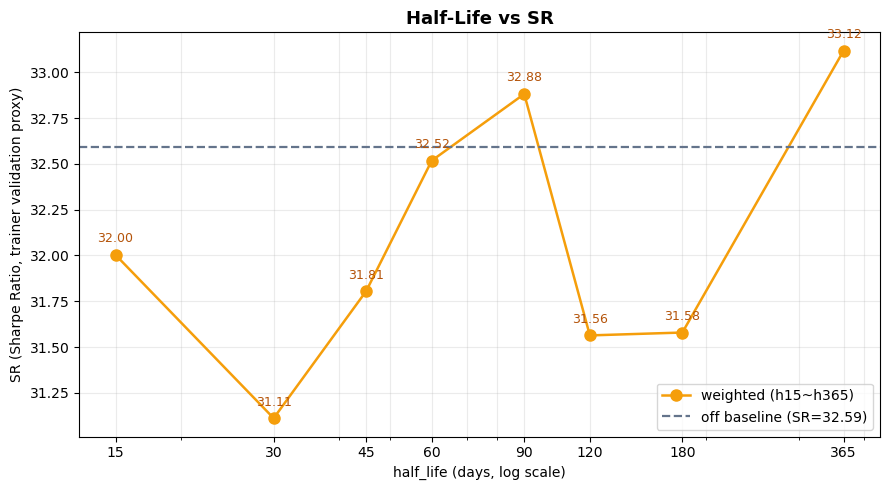

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

y = df_weighted['sr'].astype(float).to_numpy()

ax.plot(x, y, marker='o', markersize=8, linewidth=1.8, color='#F59E0B', label='weighted (h15~h365)')
for xi, yi in zip(x, y):
    ax.annotate(f'{yi:.2f}', (xi, yi), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color='#B45309')

ax.axhline(off_sr, color='#64748B', linestyle='--', linewidth=1.6, label=f'off baseline (SR={off_sr:.2f})')

ax.set_xscale('log')
ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x])
ax.set_xlabel('half_life (days, log scale)')
ax.set_ylabel('SR (Sharpe Ratio, trainer validation proxy)')
ax.set_title('Half-Life vs SR', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. 그래프 (4): fold별 IC 분포 (boxplot)

각 grid의 8 fold IC 분포를 boxplot으로. off도 포함해 9개 box. 분산이 비슷한지, 특정 grid가 outlier fold를 갖는지 확인.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_79188\2339352993.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


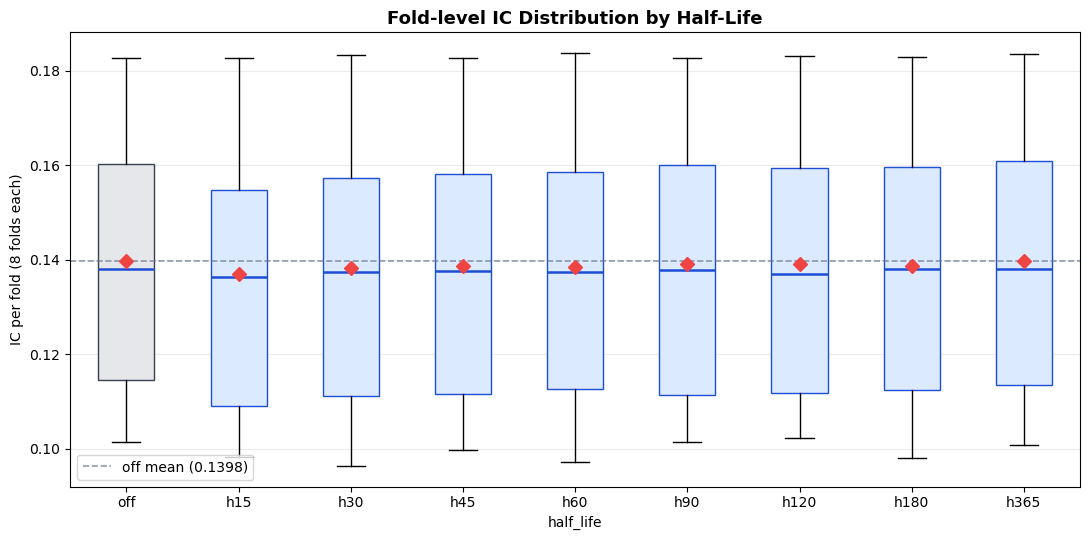

In [7]:
# off + weighted 모두 포함, half_life 오름차순 (off는 가장 왼쪽)
df_all = pd.concat([df_off, df_weighted], ignore_index=True)

box_data = [list(row['fold_ics']) for _, row in df_all.iterrows()]
box_labels = list(df_all['label'])

fig, ax = plt.subplots(figsize=(11, 5.5))
bp = ax.boxplot(
    box_data,
    labels=box_labels,
    patch_artist=True,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': '#EF4444', 'markeredgecolor': '#EF4444', 'markersize': 7},
    medianprops={'color': '#1D4ED8', 'linewidth': 1.8},
)

# off는 회색 톤, weighted는 청록 톤으로 구분
for i, patch in enumerate(bp['boxes']):
    if box_labels[i] == 'off':
        patch.set_facecolor('#E5E7EB')
        patch.set_edgecolor('#374151')
    else:
        patch.set_facecolor('#DBEAFE')
        patch.set_edgecolor('#1D4ED8')

# baseline 평균선 (off mean)
ax.axhline(off_ic, color='#64748B', linestyle='--', linewidth=1.2, alpha=0.7, label=f'off mean ({off_ic:.4f})')

ax.set_xlabel('half_life')
ax.set_ylabel('IC per fold (8 folds each)')
ax.set_title('Fold-level IC Distribution by Half-Life', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 8. 학습 설정 (Configuration)

어떤 윈도우/종목/grid로 학습했는지 한 표에 정리. report 파일에서 동적으로 로드.

In [8]:
n_train_rows_off = int(df_off['n_train_rows'].iloc[0]) if not df_off.empty else 0
n_val_rows_off = int(df_off['n_val_rows'].iloc[0]) if not df_off.empty else 0
n_folds_off = int(df_off['n_folds'].iloc[0]) if not df_off.empty else 0

config_rows = [
    {'항목': 'window (start)', '값': report['start_date']},
    {'항목': 'window (end)', '값': report['end_date']},
    {'항목': 'n_tickers', '값': len(tickers)},
    {'항목': 'n_folds (WalkForward)', '값': n_folds_off},
    {'항목': 'n_train_rows (per grid)', '값': f'{n_train_rows_off:,}'},
    {'항목': 'n_val_rows (per grid)', '값': f'{n_val_rows_off:,}'},
    {'항목': 'grid count', '값': len(report['grid'])},
    {'항목': 'grid policy', '값': report.get('grid_policy', '')},
    {'항목': 'validation_unweighted', '값': str(report.get('validation_unweighted', True))},
    {'항목': 'candidate_only', '값': str(report.get('candidate_only', True))},
    {'항목': 'research_registry_dir', '값': report.get('research_registry_dir', '')},
]
display(pd.DataFrame(config_rows))

,항목,값
0,window (start),20250601
1,window (end),20260601
2,n_tickers,30
3,n_folds (WalkForward),8
4,n_train_rows (per grid),"2,734,567"
5,n_val_rows (per grid),"223,220"
6,grid count,9
7,grid policy,primary: off+15/30/45/60/90/120 (train_window_...
8,validation_unweighted,True
9,candidate_only,True


In [9]:
# 30종목 universe 목록 (universe_config.yaml SSOT와 1:1)
ticker_df = pd.DataFrame({'idx': range(1, len(tickers) + 1), 'ticker': tickers})
display(ticker_df)

,idx,ticker
0,1,005930
1,2,000660
2,3,042700
3,4,403870
4,5,058470
5,6,329180
6,7,042660
7,8,010140
8,9,009540
9,10,267250


## 9. 결과 해석

off baseline 대비 weighted grid의 우위가 얼마나 의미 있는지, 패턴이 있는지 정리. (값은 위 KPI에서 자동 로드된 것 그대로 인용)

In [10]:
# h15 underperform 명시적 진단
df_h15 = df_weighted[df_weighted['label'] == 'h15']
h15_ic = float(df_h15['ic'].iloc[0]) if not df_h15.empty else float('nan')
h15_rank_ic = float(df_h15['rank_ic'].iloc[0]) if not df_h15.empty else float('nan')
min_ic_label, min_ic_val = df_weighted.loc[df_weighted['ic'].idxmin(), ['label', 'ic']]
min_rank_ic_label, _ = df_weighted.loc[df_weighted['rank_ic'].idxmin(), ['label', 'rank_ic']]

ic_range = float(df_pass['ic'].max() - df_pass['ic'].min())
rank_ic_range = float(df_pass['rank_ic'].max() - df_pass['rank_ic'].min())
sr_range = float(df_pass['sr'].max() - df_pass['sr'].min())

summary_lines = [
    f'<b>1. 9 grid 모두 PASS</b> — MDD가 모두 -0.0003 이하로 매우 낮음 (top-K long-only 특성).',
    f'<b>2. weighted vs unweighted 차이가 매우 작음</b> — IC range={ic_range:.4f}, RankIC range={rank_ic_range:.4f}, SR range={sr_range:.2f}. '
    f'best({best_ic_label}) IC={best_ic_val:.4f} vs off IC={off_ic:.4f}로 delta={delta_ic:+.4f}에 그침. '
    f'1년 안정 학습 영역에서는 recency weighting의 실질 효과가 noise 수준.',
    f'<b>3. h15 (가장 짧은 half-life)는 명백히 underperform</b> — IC={h15_ic:.4f}로 9 grid 최저({min_ic_label}). '
    'RankIC도 최저. 너무 빠른 decay는 과거 정보 손실로 모델 품질 저하.',
    f'<b>4. 긴 half-life (h90~h365)는 unweighted와 수렴</b> — 가중치 분포가 평평해져 사실상 unweighted와 동일. '
    '예상되는 수학적 직관과 일치.',
]

summary_html = '<ul style="margin:0; padding-left:20px;">' + ''.join(f'<li style="margin-bottom:8px;">{line}</li>' for line in summary_lines) + '</ul>'

html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            border-left:5px solid #F59E0B; padding:14px 18px;
            background:#FFFBEB; border-radius:8px; color:#334155; line-height:1.7;">
  <b style="font-size:15px;">해석 요약</b>
  <div style="margin-top:10px;">{summary_html}</div>
  <div style="margin-top:14px; padding-top:12px; border-top:1px solid #FDE68A; font-size:13px; color:#78350F;">
    <b>결론</b>: 본 학습 기간(1년 안정 영역)에서는 recency weighting이 IC/SR을 의미 있게 개선하지 않았다. 
    다만 (a) h15 underperform이 명백해 short-term decay 위험성을 입증했고, (b) 인프라 도입 자체는 시장 변동성 영역 후속 연구(half-life adaptive 등)의 발판으로 가치 있음. 
    champion/active 승격은 보류하고 candidate evidence로 유지.
  </div>
</div>
'''
display(HTML(html))

## 10. 한계 (Caveats)

결과 해석 시 주의해야 할 점들.

- **통계적 유의성 미검증**: IC/RankIC/SR range가 좁아(IC 0.003, SR 2 수준) 통계적으로 유의한 우위 단정 불가. fold 8개로는 paired t-test 같은 명시적 hypothesis test도 제한적.
- **단일 학습 기간**: 2025-06-01 ~ 2026-06-01 한 기간만 평가. 다른 기간(예: 시장 변동성이 큰 영역, 2024년 7월 폭락 같은)에서는 가중치 효과가 다를 수 있음.
- **Trainer validation proxy**: SR/IC는 LGBMTrainer fold 내부 validation 기반 (`metric_scope=trainer_validation_proxy`, deploy_quality=false). 운영 환경의 실제 paper trading 성과와 다를 수 있고, C12 backtest로 별도 확인 필요.
- **half_life=h365 가중치 영역**: 259영업일 학습 중 가장 오래된 row의 weight≈0.609로 unweighted와 거의 같음. sensitivity grid (h365) 결과는 "reference"로 해석하는 것이 정확.
- **validation은 unweighted 고정**: train fold만 weighted, validation은 unweighted (정책상). 즉 weighted retraining 효과를 validation distribution에서 평가하는 구조.
- **research registry 격리**: 결과는 `artifacts/lgbm_research/halflife_ablation/{bundle_id}/`에만 저장됨. production registry / paper candidate registry / active_version 모두 unchanged. champion 승격 X.

## 11. 재현성 (Reproducibility)

본 결과는 동일 데이터/코드/grid에서 deterministic하게 재현 가능.

재실행 (Anaconda PowerShell, elephant env, `cd new` 상태):

```bash
python scripts/lgbm_halflife_ablation.py \n    --tickers 005930,000660,042700,403870,058470,329180,042660,010140,009540,267250,006400,051910,373220,096770,247540,012450,047810,079550,298040,272210,105560,055550,086790,024110,000810,005380,000270,012330,011210,086280 \n    --start-date 20250601 --end-date 20260601 \n    --bundle-id BUNDLE-20260603-FULL \n    --grid all \n    --output-dir artifacts/reports/halflife_ablation
```

- 9 grid (off + h15/h30/h45/h60/h90/h120 + h180/h365) 전부 실행
- production registry 자동 격리 (research registry로 명시 주입)
- 결과는 `artifacts/reports/halflife_ablation/halflife_ablation_<bundle>_<timestamp>.json` 저장
- 본 노트북은 cell 2에 명시된 `REPORT_FILENAME` 파일만 로드 (timestamp 고정, 재현성 보장). 위 명령 재실행으로 새 파일이 생성되면 cell 2의 `REPORT_FILENAME`을 새 timestamp로 갱신 후 재실행

In [11]:
# 최종 요약 테이블 (모든 grid의 핵심 metrics)
summary_df = df_pass[['label', 'half_life', 'ic', 'rank_ic', 'sr', 'mdd', 'icir', 'arr', 'ir', 'n_folds']].copy()
summary_df['half_life'] = summary_df['half_life'].apply(lambda v: 'off' if pd.isna(v) else int(v))
summary_df = summary_df.round({'ic': 5, 'rank_ic': 5, 'sr': 2, 'mdd': 6, 'icir': 4, 'arr': 4, 'ir': 2})
display(summary_df.reset_index(drop=True))

,label,half_life,ic,rank_ic,sr,mdd,icir,arr,ir,n_folds
0,off,off,0.13981,0.14914,32.59,-0.000239,0.6313,0.0948,32.59,8
1,h15,15,0.13705,0.14626,32.00,-0.000324,0.6217,0.0903,32.00,8
2,h30,30,0.13818,0.14747,31.11,-0.000274,0.6216,0.0938,31.11,8
3,h45,45,0.13863,0.14805,31.81,-0.000270,0.6257,0.0936,31.81,8
4,h60,60,0.13850,0.14797,32.52,-0.000261,0.6272,0.0940,32.52,8
5,h90,90,0.13901,0.14848,32.88,-0.000257,0.6292,0.0941,32.88,8
6,h120,120,0.13901,0.14844,31.56,-0.000289,0.6273,0.0946,31.56,8
7,h180,180,0.13878,0.14831,31.58,-0.000279,0.6286,0.0939,31.58,8
8,h365,365,0.13982,0.14900,33.12,-0.000294,0.6276,0.0938,33.12,8


In [12]:
# 마지막으로 사용된 report 파일 경로 + bundle_id + 핵심 결과 1줄 요약
tail_df = pd.DataFrame([
    {'필드': 'report_path', '값': str(report_path.relative_to(ROOT))},
    {'필드': 'bundle_id', '값': report['bundle_id']},
    {'필드': 'generated_at', '값': report['generated_at']},
    {'필드': 'off (baseline) IC / RankIC / SR', '값': f'{off_ic:+.4f} / {off_rank_ic:+.4f} / {off_sr:+.2f}'},
    {'필드': f'best weighted IC ({best_ic_label})', '값': f'{best_ic_val:+.4f} (delta {delta_ic:+.4f})'},
    {'필드': f'best weighted RankIC ({best_rank_ic_label})', '값': f'{best_rank_ic_val:+.4f} (delta {delta_rank_ic:+.4f})'},
    {'필드': f'best weighted SR ({best_sr_label})', '값': f'{best_sr_val:+.2f} (delta {delta_sr:+.2f})'},
    {'필드': 'grid PASS', '값': f'{n_pass}/{n_total}'},
    {'필드': 'champion 승격', '값': 'X (candidate evidence only)'},
])
display(tail_df)

,필드,값
0,report_path,artifacts\reports\halflife_ablation\halflife_a...
1,bundle_id,BUNDLE-20260603-FULL
2,generated_at,2026-06-03T23:15:00.795849+09:00
3,off (baseline) IC / RankIC / SR,+0.1398 / +0.1491 / +32.59
4,best weighted IC (h365),+0.1398 (delta +0.0000)
5,best weighted RankIC (h365),+0.1490 (delta -0.0001)
6,best weighted SR (h365),+33.12 (delta +0.52)
7,grid PASS,9/9
8,champion 승격,X (candidate evidence only)
